In [1]:
# ==========================================================
# Vision Transformer from Scratch on CIFAR-10/CIFAR-100
# IIT Delhi CV Assignment
# ==========================================================

import os
import math
import random
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10, CIFAR100
import torchvision.transforms as transforms

from tqdm.auto import tqdm

print("Torch Version :", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


Torch Version : 2.10.0+cu128
Device : cuda
Tesla T4


In [2]:
def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = True

seed_everything()

In [3]:
IMAGE_SIZE = 32

PATCH_SIZE = 4

IN_CHANNELS = 3

NUM_CLASSES = 100

EMBED_DIM = 192

DEPTH = 9

NUM_HEADS = 3

MLP_RATIO = 4

BATCH_SIZE = 128

EPOCHS = 100       # DEBUG FIRST

LR = 3e-4

WEIGHT_DECAY = 0.05

In [4]:
mean = (0.4914,0.4822,0.4465)

std = (0.2470,0.2435,0.2616)

train_transform = transforms.Compose([

    transforms.RandomCrop(32,padding=4),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(mean,std)

])

test_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(mean,std)

])

In [5]:
train_dataset = CIFAR100(

    root="./data",

    train=True,

    download=True,

    transform=train_transform

)

test_dataset = CIFAR100(

    root="./data",

    train=False,

    download=True,

    transform=test_transform

)

100%|██████████| 169M/169M [42:42<00:00, 66.0kB/s]


In [6]:
train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=4,

    pin_memory=True,

    persistent_workers=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True,

    persistent_workers=True

)

In [7]:
images,labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

torch.Size([128, 3, 32, 32])
torch.Size([128])


In [8]:
class PatchEmbedding(nn.Module):

    def __init__(
        self,
        image_size=32,
        patch_size=4,
        in_channels=3,
        embed_dim=192
    ):
        super().__init__()

        self.image_size = image_size
        self.patch_size = patch_size

        self.num_patches = (image_size // patch_size) ** 2

        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):

        x = self.proj(x)

        x = x.flatten(2)

        x = x.transpose(1,2)

        return x

In [9]:
patch_embed = PatchEmbedding()

dummy = torch.randn(2,3,32,32)

out = patch_embed(dummy)

print(out.shape)

torch.Size([2, 64, 192])


In [10]:
class ViTEmbedding(nn.Module):

    def __init__(
        self,
        image_size=32,
        patch_size=4,
        in_channels=3,
        embed_dim=192
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(
            torch.zeros(1,1,embed_dim)
        )

        self.pos_embedding = nn.Parameter(
            torch.zeros(1,num_patches+1,embed_dim)
        )

    def forward(self,x):

        B = x.shape[0]

        x = self.patch_embed(x)

        cls = self.cls_token.expand(B,-1,-1)

        x = torch.cat((cls,x),dim=1)

        x = x + self.pos_embedding

        return x

In [11]:
embedding = ViTEmbedding()

dummy = torch.randn(2,3,32,32)

out = embedding(dummy)

print(out.shape)

torch.Size([2, 65, 192])


In [12]:
class MultiHeadSelfAttention(nn.Module):

    def __init__(
        self,
        embed_dim=192,
        num_heads=3,
        dropout=0.1
    ):
        super().__init__()

        self.embed_dim = embed_dim
        self.num_heads = num_heads

        assert embed_dim % num_heads == 0

        self.head_dim = embed_dim // num_heads

        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)

        self.attn_drop = nn.Dropout(dropout)

        self.proj = nn.Linear(embed_dim, embed_dim)

        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):

        B,N,C = x.shape

        qkv = self.qkv(x)

        qkv = qkv.reshape(
            B,
            N,
            3,
            self.num_heads,
            self.head_dim
        )

        qkv = qkv.permute(2,0,3,1,4)

        q,k,v = qkv[0],qkv[1],qkv[2]

        attn = (q @ k.transpose(-2,-1)) * self.scale

        attn = attn.softmax(dim=-1)

        attn = self.attn_drop(attn)

        x = attn @ v

        x = x.transpose(1,2).reshape(B,N,C)

        x = self.proj(x)

        x = self.proj_drop(x)

        return x

In [13]:
attention = MultiHeadSelfAttention()

dummy = torch.randn(2,65,192)

out = attention(dummy)

print(out.shape)

torch.Size([2, 65, 192])


In [14]:
class MLP(nn.Module):

    def __init__(
        self,
        embed_dim=192,
        mlp_ratio=4,
        dropout=0.1
    ):
        super().__init__()

        hidden_dim = embed_dim * mlp_ratio

        self.net = nn.Sequential(

            nn.Linear(embed_dim, hidden_dim),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(hidden_dim, embed_dim),

            nn.Dropout(dropout)

        )

    def forward(self, x):

        return self.net(x)

In [15]:
class TransformerEncoderBlock(nn.Module):

    def __init__(
        self,
        embed_dim=192,
        num_heads=3,
        mlp_ratio=4,
        dropout=0.1
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attn = MultiHeadSelfAttention(
            embed_dim,
            num_heads,
            dropout
        )

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = MLP(
            embed_dim,
            mlp_ratio,
            dropout
        )

    def forward(self, x):

        x = x + self.attn(self.norm1(x))

        x = x + self.mlp(self.norm2(x))

        return x

In [16]:
encoder = TransformerEncoderBlock()

dummy = torch.randn(2,65,192)

out = encoder(dummy)

print(out.shape)

torch.Size([2, 65, 192])


In [17]:
class VisionTransformer(nn.Module):

    def __init__(
        self,
        image_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=192,
        depth=9,
        num_heads=3,
        mlp_ratio=4,
        dropout=0.1
    ):
        super().__init__()

        self.embedding = ViTEmbedding(
            image_size,
            patch_size,
            in_channels,
            embed_dim
        )

        self.encoder = nn.Sequential(*[
            TransformerEncoderBlock(
                embed_dim,
                num_heads,
                mlp_ratio,
                dropout
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        self.head = nn.Linear(
            embed_dim,
            num_classes
        )

    def forward(self, x):

        x = self.embedding(x)

        x = self.encoder(x)

        x = self.norm(x)

        cls = x[:,0]

        return self.head(cls)

In [18]:
vit = VisionTransformer().to(device)

dummy = torch.randn(2,3,32,32).to(device)

out = vit(dummy)

print(out.shape)

torch.Size([2, 10])


In [19]:
class CNNBaseline(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(

            # Stage 1
            nn.Conv2d(3, 96, 3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),

            nn.Conv2d(96, 96, 3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Stage 2
            nn.Conv2d(96, 192, 3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),

            nn.Conv2d(192, 192, 3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Stage 3
            nn.Conv2d(192, 384, 3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, 3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            # Stage 4
            nn.Conv2d(384, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):

        x = self.features(x)

        x = x.flatten(1)

        return self.classifier(x)



In [20]:
cnn = CNNBaseline().to(device)

dummy = torch.randn(2,3,32,32).to(device)

out = cnn(dummy)

print(out.shape)

torch.Size([2, 10])


In [21]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

vit = VisionTransformer()

cnn = CNNBaseline()

vit_params = count_parameters(vit)

cnn_params = count_parameters(cnn)

print(f"ViT Parameters : {vit_params:,}")

print(f"CNN Parameters : {cnn_params:,}")

difference = abs(vit_params-cnn_params)/vit_params*100

print(f"Difference : {difference:.2f}%")

ViT Parameters : 4,028,170
CNN Parameters : 4,354,026
Difference : 8.09%


In [22]:
vit = VisionTransformer(num_classes=100).to(device)

optimizer = torch.optim.AdamW(
    vit.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

In [23]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

In [24]:
criterion = nn.CrossEntropyLoss()

In [25]:
scaler = torch.amp.GradScaler("cuda")

In [26]:
def train_one_epoch(model,
                    loader,
                    optimizer,
                    criterion,
                    scaler):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, leave=False)

    for images, labels in pbar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(
            loss=f"{running_loss/(total/labels.size(0)):.3f}",
            acc=f"{100.*correct/total:.2f}%"
        )

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

In [27]:
def validate(model,
             loader,
             criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

In [28]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_acc = 0

vit = VisionTransformer(num_classes=100).to(device)


optimizer = torch.optim.AdamW(
    vit.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        vit,
        train_loader,
        optimizer,
        criterion,
        scaler
    )

    val_loss, val_acc = validate(
        vit,
        test_loader,
        criterion
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")
    print(f"LR         : {scheduler.get_last_lr()[0]:.6f}")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(vit.state_dict(), "best_vit_cifar100.pth")

print(f"\nBest Validation Accuracy: {best_acc:.2f}%")


     


Epoch 1/100


  0%|          | 0/391 [00:00<?, ?it/s]

Train Loss : 3.9585
Train Acc  : 9.26%
Val Loss   : 3.6150
Val Acc    : 14.06%
LR         : 0.000300

Epoch 2/100


  0%|          | 0/391 [00:00<?, ?it/s]

Train Loss : 3.4325
Train Acc  : 17.57%
Val Loss   : 3.2097
Val Acc    : 21.05%
LR         : 0.000300

Epoch 3/100


...

Train Loss : 0.0331
Train Acc  : 99.22%
Val Loss   : 2.4330
Val Acc    : 58.32%
LR         : 0.000000

Epoch 99/100


  0%|          | 0/391 [00:00<?, ?it/s]

Train Loss : 0.0334
Train Acc  : 99.17%
Val Loss   : 2.4332
Val Acc    : 58.38%
LR         : 0.000000

Epoch 100/100


  0%|          | 0/391 [00:00<?, ?it/s]

Train Loss : 0.0314
Train Acc  : 99.24%
Val Loss   : 2.4332
Val Acc    : 58.38%
LR         : 0.000000

Best Validation Accuracy: 58.39%


In [29]:
import torch

def evaluate_topk(model, loader, device, k=5):
    model.eval()

    top1_correct = 0
    top5_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # Top-1
            _, pred = outputs.max(1)
            top1_correct += pred.eq(labels).sum().item()

            # Top-5
            _, top5 = outputs.topk(k, dim=1)
            top5_correct += top5.eq(labels.view(-1, 1)).sum().item()

            total += labels.size(0)

    top1 = 100 * top1_correct / total
    top5 = 100 * top5_correct / total

    return top1, top5

In [30]:
vit = VisionTransformer(num_classes=100).to(device)

vit.load_state_dict(torch.load("best_vit_cifar100.pth", map_location=device))

vit.eval()

top1, top5 = evaluate_topk(vit, test_loader, device, k=5)

print(f"ViT Top-1 Accuracy : {top1:.2f}%")
print(f"ViT Top-5 Accuracy : {top5:.2f}%")

ViT Top-1 Accuracy : 58.39%
ViT Top-5 Accuracy : 82.46%


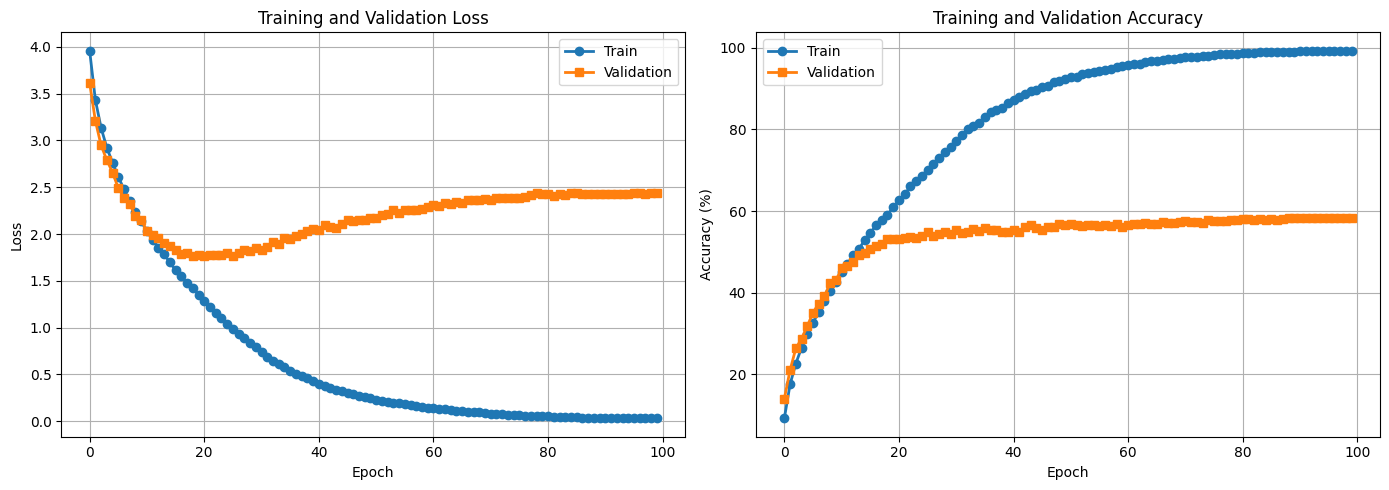

In [31]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(train_losses, marker='o', linewidth=2, label='Train')
plt.plot(val_losses, marker='s', linewidth=2, label='Validation')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, marker='o', linewidth=2, label='Train')
plt.plot(val_accs, marker='s', linewidth=2, label='Validation')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [32]:
model = CNNBaseline(num_classes=100).to(device)

In [33]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

In [34]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

In [35]:
scaler = torch.amp.GradScaler("cuda")

In [36]:
criterion = nn.CrossEntropyLoss()

In [37]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_acc = 0

model = CNNBaseline(num_classes=100).to(device)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler
    )

    val_loss, val_acc = validate(
        model,
        test_loader,
        criterion
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")
    print(f"LR         : {scheduler.get_last_lr()[0]:.6f}")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(model.state_dict(), "best_cnn_cifar100.pth")

print(f"\nBest Validation Accuracy: {best_acc:.2f}%")


     


Epoch 1/100


  0%|          | 0/391 [00:00<?, ?it/s]

Train Loss : 3.5389
Train Acc  : 16.13%
Val Loss   : 3.0766
Val Acc    : 22.26%
LR         : 0.000300

Epoch 2/100


  0%|          | 0/391 [00:00<?, ?it/s]

Train Loss : 2.7241
Train Acc  : 30.92%
Val Loss   : 2.4821
Val Acc    : 34.74%
LR         : 0.000300

Epoch 3/100


...

Train Loss : 0.0041
Train Acc  : 99.97%
Val Loss   : 1.5637
Val Acc    : 71.45%
LR         : 0.000000

Epoch 99/100


  0%|          | 0/391 [00:00<?, ?it/s]

Train Loss : 0.0037
Train Acc  : 99.98%
Val Loss   : 1.5669
Val Acc    : 71.47%
LR         : 0.000000

Epoch 100/100


  0%|          | 0/391 [00:00<?, ?it/s]

Train Loss : 0.0040
Train Acc  : 99.97%
Val Loss   : 1.5649
Val Acc    : 71.42%
LR         : 0.000000

Best Validation Accuracy: 71.57%


In [38]:
import torch

def evaluate_topk(model, loader, device, k=5):
    model.eval()

    top1_correct = 0
    top5_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # Top-1
            _, pred = outputs.max(1)
            top1_correct += pred.eq(labels).sum().item()

            # Top-5
            _, top5 = outputs.topk(k, dim=1)

            top5_correct += (
                top5.eq(labels.view(-1,1))
                    .sum()
                    .item()
            )

            total += labels.size(0)

    top1 = 100 * top1_correct / total
    top5 = 100 * top5_correct / total

    return top1, top5

In [39]:
top1, top5 = evaluate_topk(
    model,
    test_loader,
    device,
    k=5
)

print(f"Top-1 Accuracy : {top1:.2f}%")
print(f"Top-5 Accuracy : {top5:.2f}%")

Top-1 Accuracy : 71.42%
Top-5 Accuracy : 91.58%


In [40]:
import os

print(os.getcwd())
print(os.listdir())

/kaggle/working
['__notebook__.ipynb', 'best_cnn_cifar100.pth', 'best_vit_cifar100.pth', 'data']


In [41]:
print(type(vit))

<class '__main__.VisionTransformer'>


In [42]:
top1, top5 = evaluate_topk(vit, test_loader, device, k=5)

print(f"ViT Top-1 : {top1:.2f}%")
print(f"ViT Top-5 : {top5:.2f}%")

ViT Top-1 : 58.39%
ViT Top-5 : 82.46%


In [43]:
print(vit)

VisionTransformer(
  (embedding): ViTEmbedding(
    (patch_embed): PatchEmbedding(
      (proj): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
    )
  )
  (encoder): Sequential(
    (0): TransformerEncoderBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (attn_drop): Dropout(p=0.1, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (net): Sequential(
          (0): Linear(in_features=192, out_features=768, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=768, out_features=192, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (1): TransformerEncode

In [44]:
import os
print(os.listdir())

['__notebook__.ipynb', 'best_cnn_cifar100.pth', 'best_vit_cifar100.pth', 'data']


In [45]:
torch.save(vit.state_dict(), "best_vit_cifar100.pth")